# Counterfactual Explanations

Two approaches here: DiCE for algorithmic counterfactuals, and simpler "what if" scenarios from the pipeline. Both answer the question "what would need to change for this customer to be predicted as lower risk?"


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import dice_ml
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

ROOT = Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "credit_risk_model_table.csv")
target = "default_next_month"
drop_columns = ["customer_id", "statement_month", target]
X = df.drop(columns=drop_columns)
y = df[target]

categorical = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric = [column for column in X.columns if column not in categorical]

preprocess = ColumnTransformer([
    ("numeric", "passthrough", numeric),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=120,
        max_depth=6,
        min_samples_leaf=35,
        random_state=42,
    )),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['limit_balance','annual_income','sex',...,'pay_amt_4','pay_amt_5', 'pay_amt_6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [2]:
training_frame = X_train.copy()
training_frame[target] = y_train.to_numpy()

dice_data = dice_ml.Data(
    dataframe=training_frame,
    continuous_features=numeric,
    outcome_name=target,
)
dice_model = dice_ml.Model(
    model=model,
    backend="sklearn",
    model_type="classifier",
)
explainer = dice_ml.Dice(dice_data, dice_model, method="random")


In [3]:
candidate_scores = pd.Series(
    model.predict_proba(X_test)[:, 1],
    index=X_test.index,
    name="predicted_pd",
)
query_instance = X_test.loc[[candidate_scores.idxmax()]]
query_instance


,limit_balance,annual_income,sex,education,marital_status,age,age_group,credit_limit_band,utilization_ratio,payment_ratio,...,bill_amt_3,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6
3001,52000.0,61124.0,male,high_school,single,46,40_to_49,low,0.7187,0.2648,...,35751.0,33816.0,37076.0,39739.0,6361.0,8656.0,8078.0,7255.0,15044.0,13977.0


In [4]:
try:
    dice_explanation = explainer.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=[
            "utilization_ratio",
            "payment_ratio",
            "months_with_delay",
            "pay_status_1",
            "pay_status_2",
            "pay_status_3",
            "pay_status_4",
            "pay_status_5",
            "pay_status_6",
        ],
        permitted_range={
            "utilization_ratio": [0.05, 0.75],
            "payment_ratio": [0.25, 0.85],
            "months_with_delay": [0, 3],
            "pay_status_1": [0, 2],
            "pay_status_2": [0, 2],
            "pay_status_3": [0, 2],
            "pay_status_4": [0, 2],
            "pay_status_5": [0, 2],
            "pay_status_6": [0, 2],
        },
    )
    dice_explanation.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print(f"DiCE generation encountered an issue: {type(e).__name__}")
    print("Continuing with the pipeline counterfactual examples below.")


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.04it/s]

100%|██████████| 1/1 [00:00<00:00,  2.04it/s]

Query instance (original outcome : 1)


,limit_balance,annual_income,sex,education,marital_status,age,age_group,credit_limit_band,utilization_ratio,payment_ratio,...,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_next_month
0,52000.0,61124.0,male,high_school,single,46,40_to_49,low,0.7187,0.2648,...,33816.0,37076.0,39739.0,6361.0,8656.0,8078.0,7255.0,15044.0,13977.0,1



Diverse Counterfactual set (new outcome: 0)


,limit_balance,annual_income,sex,education,marital_status,age,age_group,credit_limit_band,utilization_ratio,payment_ratio,...,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_next_month
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0
1,-,-,-,-,-,-,-,-,0.633,-,...,-,-,-,-,-,-,-,-,-,0
2,-,-,-,-,-,-,-,-,0.1799,-,...,-,-,-,-,-,-,-,-,-,0


In [5]:
counterfactuals = pd.read_csv(ROOT / "data" / "processed" / "counterfactual_examples.csv")

summary = (
    counterfactuals
    .groupby("counterfactual_action")
    .agg(
        examples=("customer_id", "count"),
        average_starting_pd=("baseline_pd", "mean"),
        average_counterfactual_pd=("counterfactual_pd", "mean"),
        average_pd_reduction=("pd_reduction", "mean"),
    )
    .reset_index()
    .sort_values("average_pd_reduction", ascending=False)
)
summary


,counterfactual_action,examples,average_starting_pd,average_counterfactual_pd,average_pd_reduction
0,combined,8,0.912187,0.034330,0.877857
1,improve_repayment,8,0.912187,0.075474,0.836713
2,lower_utilization,8,0.912187,0.672757,0.239429


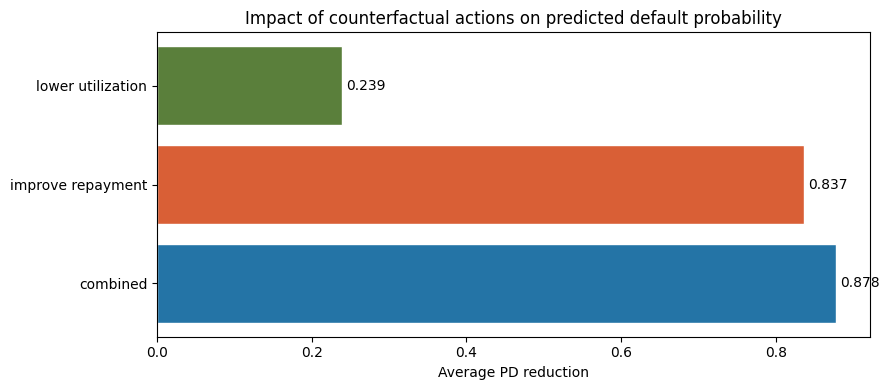

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2474a6", "#d95f36", "#5a7f3b"]
bars = ax.barh(
    summary["counterfactual_action"].str.replace("_", " "),
    summary["average_pd_reduction"],
    color=colors[:len(summary)], edgecolor="white",
)
ax.set_xlabel("Average PD reduction")
ax.set_title("Impact of counterfactual actions on predicted default probability")
for bar, val in zip(bars, summary["average_pd_reduction"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center")
plt.tight_layout()
plt.show()


In [7]:
pipeline_examples = (
    counterfactuals
    .sort_values("pd_reduction", ascending=False)
    .loc[:, [
        "customer_id",
        "counterfactual_description",
        "baseline_pd",
        "counterfactual_pd",
        "pd_reduction",
        "starting_utilization_ratio",
        "counterfactual_utilization_ratio",
    ]]
    .head(10)
)
pipeline_examples


,customer_id,counterfactual_description,baseline_pd,counterfactual_pd,pd_reduction,starting_utilization_ratio,counterfactual_utilization_ratio
21,3033,Combine lower utilisation with improved repaym...,0.943543,0.037421,0.906122,0.9387,0.5500
3,285,Combine lower utilisation with improved repaym...,0.943860,0.048215,0.895646,0.9256,0.5500
9,1173,Combine lower utilisation with improved repaym...,0.907423,0.030203,0.877220,0.8929,0.5500
6,458,Combine lower utilisation with improved repaym...,0.907861,0.032860,0.875001,0.9362,0.5500
18,2441,Combine lower utilisation with improved repaym...,0.902467,0.031404,0.871063,0.9361,0.5500
0,63,Combine lower utilisation with improved repaym...,0.896565,0.026193,0.870372,0.8448,0.5500
12,1523,Combine lower utilisation with improved repaym...,0.896028,0.030190,0.865838,0.9069,0.5500
15,2144,Combine lower utilisation with improved repaym...,0.899748,0.038151,0.861597,0.9728,0.5500
22,3033,Improve recent repayment pattern and payment r...,0.943543,0.084926,0.858617,0.9387,0.9387
1,63,Improve recent repayment pattern and payment r...,0.896565,0.047675,0.848890,0.8448,0.8448


The combined scenario (lower utilization + improved repayment) produces the largest PD reduction on average, which makes sense because it addresses both the balance risk and the behavioural signal simultaneously. These are model-implied sensitivities, not causal claims.
